
# Visualizzazione atomistica in Jupyter: OVITO + py3Dmol

Questo notebook è pensato come esempio didattico per il corso e per l'uso in **VS Code/Jupyter**.

Contiene due casi:

1. **Ag FCC + Lennard–Jones**  
   - breve dinamica molecolare in unità ridotte;
   - esportazione della traiettoria in Extended XYZ;
   - import e analisi con **OVITO**;
   - viewer 3D **OVITO interattivo direttamente nella cella Jupyter**.

2. **Ala\(_4\) in acqua**  
   - tetrapeptide Ala–Ala–Ala–Ala;
   - piccola scatola d'acqua illustrativa;
   - visualizzazione con **py3Dmol**.

> **Nota fisica.** Lennard–Jones non è un potenziale realistico per l'argento metallico. Qui viene usato soltanto per avere un esempio compatto e trasparente. Per Ag quantitativo si userebbero tipicamente potenziali many-body, per esempio EAM.

> **Nota Jupyter Book.** Il widget 3D di OVITO è pensato soprattutto per un notebook live. Per la pubblicazione statica del Jupyter Book non è indispensabile che il widget venga incorporato: il resto del notebook e i grafici rimangono validi.



## 0. Ambiente

Nel tuo ambiente del corso sono richiesti:

```bash
python -m pip install ovito py3Dmol ipywidgets ipykernel numpy matplotlib
```

Per questo progetto è meglio registrare poi le dipendenze anche nel `pyproject.toml`.

Il notebook **non installa pacchetti da solo**.


In [1]:
import sys
from pathlib import Path

import ipywidgets
import matplotlib.pyplot as plt
import numpy as np
import ovito
import py3Dmol

print("Python     :", sys.version.split()[0])
print("NumPy      :", np.__version__)
print("OVITO      :", ovito.version_string)
print("py3Dmol    :", getattr(py3Dmol, "__version__", "versione non esposta"))
print("ipywidgets :", ipywidgets.__version__)
print("cwd        :", Path.cwd())

OUT = Path("generated")
OUT.mkdir(exist_ok=True)

print("output     :", OUT.resolve())


Python     : 3.12.14
NumPy      : 2.5.3
OVITO      : 3.16.1
py3Dmol    : 2.5.5
ipywidgets : 8.1.9
cwd        : /Users/francesco/Desktop/computational-course/book/03_guide_examplenotebook
output     : /Users/francesco/Desktop/computational-course/book/03_guide_examplenotebook/generated



---

# 1. Ag FCC con Lennard–Jones

Costruiamo un cristallo FCC periodico \(4\times4\times4\), quindi:

\[
N = 4\times 4^3 = 256
\]

atomi.

La dinamica viene integrata in **unità ridotte Lennard–Jones**:

\[
\sigma=\varepsilon=m=1,
\]

con

\[
U(r)=4\varepsilon\left[
\left(\frac{\sigma}{r}\right)^{12}
-
\left(\frac{\sigma}{r}\right)^6
\right].
\]

Per esportare la struttura in Å usiamo una scala illustrativa \(\sigma_{\rm Ag}=2.644\) Å.


In [2]:
# Parametri didattici
sigma_A = 2.644
a_star = 1.55
n_cells = 4

temperature_star = 0.12
dt_star = 0.002
n_steps = 250
save_every = 10
r_cut_star = 2.5
seed = 7


def make_fcc(n_cells: int, a: float):
    """Cristallo FCC cubico periodico in unità ridotte."""
    basis = np.array(
        [
            [0.0, 0.0, 0.0],
            [0.0, 0.5, 0.5],
            [0.5, 0.0, 0.5],
            [0.5, 0.5, 0.0],
        ]
    )

    positions = []

    for i in range(n_cells):
        for j in range(n_cells):
            for k in range(n_cells):
                cell = np.array([i, j, k], dtype=float)
                positions.extend((cell + basis) * a)

    positions = np.asarray(positions, dtype=float)
    box_length = n_cells * a

    return positions, box_length


positions, box_length = make_fcc(n_cells, a_star)

print("Atomi            :", len(positions))
print("L* scatola       :", f"{box_length:.3f}")
print("L scatola [Å]    :", f"{box_length * sigma_A:.3f}")
print("a FCC [Å]        :", f"{a_star * sigma_A:.3f}")


Atomi            : 256
L* scatola       : 6.200
L scatola [Å]    : 16.393
a FCC [Å]        : 4.098



## 1.1 Forze LJ e condizioni periodiche

Usiamo:

- **minimum-image convention**;
- scatola cubica periodica;
- cutoff \(r_c=2.5\sigma\);
- potenziale traslato in modo che \(U(r_c)=0\).

L'implementazione è volutamente NumPy puro per rendere visibile il meccanismo.


In [3]:
def lj_forces(positions, box_length, r_cut=2.5):
    """Restituisce forze e potenziale LJ in unità ridotte."""
    n = len(positions)
    ii, jj = np.triu_indices(n, k=1)

    rij = positions[ii] - positions[jj]
    rij -= box_length * np.rint(rij / box_length)

    r2 = np.einsum("ij,ij->i", rij, rij)
    mask = r2 < r_cut**2

    ii = ii[mask]
    jj = jj[mask]
    rij = rij[mask]
    r2 = r2[mask]

    inv_r2 = 1.0 / r2
    inv_r6 = inv_r2**3
    inv_r12 = inv_r6**2

    scalar = 24.0 * (2.0 * inv_r12 - inv_r6) * inv_r2
    fij = scalar[:, None] * rij

    forces = np.zeros_like(positions)
    np.add.at(forces, ii, fij)
    np.add.at(forces, jj, -fij)

    u_shift = 4.0 * ((1.0 / r_cut) ** 12 - (1.0 / r_cut) ** 6)
    potential = np.sum(4.0 * (inv_r12 - inv_r6) - u_shift)

    return forces, potential



## 1.2 Breve dinamica NVE

Assegniamo velocità casuali alla temperatura desiderata, rimuoviamo il moto del centro di massa e integriamo con **velocity-Verlet**.

La simulazione è volutamente breve: serve a generare una piccola traiettoria da analizzare e visualizzare.


In [4]:
rng = np.random.default_rng(seed)

velocities = rng.normal(size=positions.shape)
velocities -= velocities.mean(axis=0)

dof = 3 * len(positions) - 3
T_initial = np.sum(velocities**2) / dof
velocities *= np.sqrt(temperature_star / T_initial)

forces, potential = lj_forces(
    positions,
    box_length,
    r_cut_star,
)

trajectory = []
thermo = []

for step in range(n_steps + 1):
    kinetic = 0.5 * np.sum(velocities**2)
    temperature = 2.0 * kinetic / dof
    total = potential + kinetic

    thermo.append((step, potential, kinetic, total, temperature))

    if step % save_every == 0:
        trajectory.append(positions.copy())

    if step == n_steps:
        break

    # velocity-Verlet
    velocities += 0.5 * dt_star * forces
    positions = (positions + dt_star * velocities) % box_length

    new_forces, potential = lj_forces(
        positions,
        box_length,
        r_cut_star,
    )

    velocities += 0.5 * dt_star * new_forces
    forces = new_forces

thermo = np.asarray(thermo)

relative_drift = (thermo[-1, 3] - thermo[0, 3]) / abs(thermo[0, 3])

print("Frame salvati    :", len(trajectory))
print("T* iniziale      :", f"{thermo[0, 4]:.4f}")
print("T* finale        :", f"{thermo[-1, 4]:.4f}")
print("Drift relativo E :", f"{relative_drift:.2e}")


Frame salvati    : 26
T* iniziale      : 0.1200
T* finale        : 0.0704
Drift relativo E : 3.60e-06


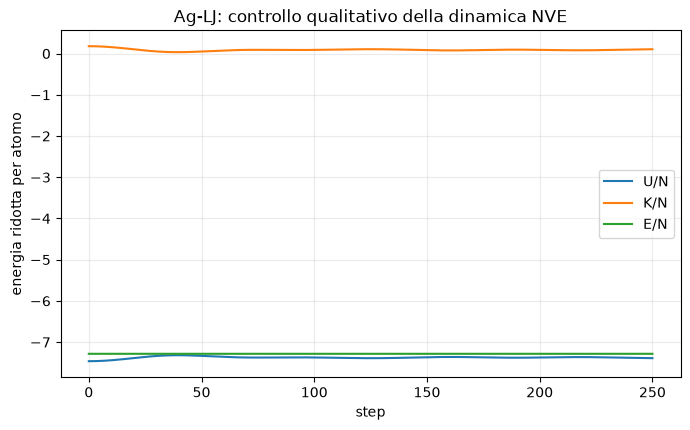

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(thermo[:, 0], thermo[:, 1] / len(positions), label="U/N")
ax.plot(thermo[:, 0], thermo[:, 2] / len(positions), label="K/N")
ax.plot(thermo[:, 0], thermo[:, 3] / len(positions), label="E/N")

ax.set_xlabel("step")
ax.set_ylabel("energia ridotta per atomo")
ax.set_title("Ag-LJ: controllo qualitativo della dinamica NVE")
ax.grid(alpha=0.25)
ax.legend()

plt.show()



## 1.3 Esportazione Extended XYZ

Salviamo una traiettoria leggibile direttamente da OVITO.

La riga di commento di ogni frame contiene:

- matrice della cella;
- periodicità;
- schema delle proprietà;
- indice del frame.


In [6]:
xyz_path = OUT / "ag_lj_trajectory.xyz"
L_A = box_length * sigma_A

with xyz_path.open("w", encoding="utf-8") as f:
    for iframe, frame in enumerate(trajectory):
        xyz = frame * sigma_A

        f.write(f"{len(xyz)}\n")
        f.write(
            'Lattice="'
            f"{L_A:.8f} 0 0 "
            f"0 {L_A:.8f} 0 "
            f'0 0 {L_A:.8f}" '
            "Properties=species:S:1:pos:R:3 "
            'pbc="T T T" '
            f"Frame={iframe}\n"
        )

        for x, y, z in xyz:
            f.write(f"Ag {x:.8f} {y:.8f} {z:.8f}\n")

print("Traiettoria:")
print(xyz_path.resolve())
print("Frame:", len(trajectory))


Traiettoria:
/Users/francesco/Desktop/computational-course/book/03_guide_examplenotebook/generated/ag_lj_trajectory.xyz
Frame: 26



---

# 2. OVITO: import e pipeline

Il pattern fondamentale dell'API Python di OVITO è:

```python
pipeline = import_file("trajectory.xyz")
data = pipeline.compute(frame)
```

La `Pipeline` descrive il flusso di elaborazione. I **modifier** vengono aggiunti alla pipeline e valutati quando chiamiamo `compute()`.


In [7]:
from ovito.io import import_file

xyz_path = Path("generated/ag_lj_trajectory.xyz")

if not xyz_path.exists():
    raise FileNotFoundError(
        "Manca generated/ag_lj_trajectory.xyz. Esegui prima le celle della simulazione."
    )

pipeline = import_file(str(xyz_path))

last_frame = pipeline.num_frames - 1
data = pipeline.compute(last_frame)

print("OVITO ha letto la traiettoria.")
print("Frame totali :", pipeline.num_frames)
print("Atomi        :", data.particles.count)
print("PBC          :", tuple(bool(v) for v in data.cell.pbc))


OVITO ha letto la traiettoria.
Frame totali : 26
Atomi        : 256
PBC          : (True, True, True)



## 2.1 Radial distribution function \(g(r)\)

`RadialDistributionFunctionModifier` calcola:

- la radial distribution function;
- il numero di coordinazione locale per ogni particella.

La tabella RDF prodotta da OVITO si chiama `coordination-rdf`.


In [8]:
from ovito.io import import_file
from ovito.modifiers import RadialDistributionFunctionModifier

rdf_pipeline = import_file("generated/ag_lj_trajectory.xyz")

rdf_pipeline.modifiers.append(
    RadialDistributionFunctionModifier(
        cutoff=7.5,
        number_of_bins=180,
    )
)

rdf_data = rdf_pipeline.compute(rdf_pipeline.num_frames - 1)

rdf = np.asarray(rdf_data.tables["coordination-rdf"].xy())

print("Tabella RDF:", rdf.shape)


Tabella RDF: (180, 2)


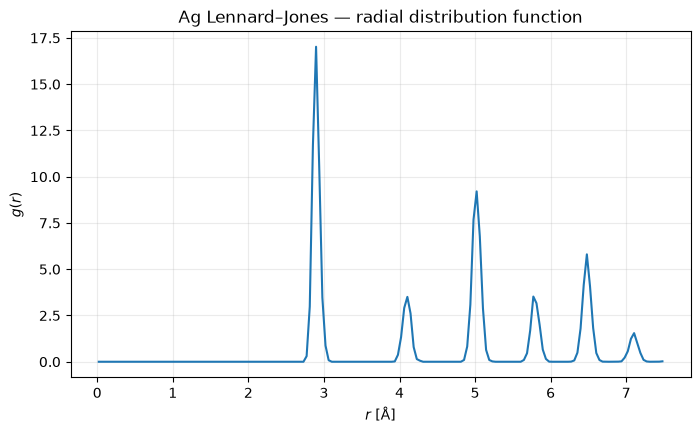

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(rdf[:, 0], rdf[:, 1])

ax.set_xlabel(r"$r$ [Å]")
ax.set_ylabel(r"$g(r)$")
ax.set_title("Ag Lennard–Jones — radial distribution function")
ax.grid(alpha=0.25)

plt.show()


---

# 3. Viewer OVITO **dentro la cella Jupyter**

Questa sezione mostra il cristallo direttamente in una cella Jupyter usando il
widget interattivo di OVITO.

Con OVITO 3.16.1 sul Mac usato per questo corso evitiamo
`create_ipywidget(pipeline)`: nel pacchetto installato quel percorso genera un
errore interno relativo a `ovito.nonpublic.Scene`.

Usiamo invece il percorso più robusto:

1. `import_file(...)`;
2. `pipeline.add_to_scene()`;
3. creazione di un `Viewport`;
4. `create_ipywidget(viewport)`.

Non usiamo `Viewport.render_image()` né `TachyonRenderer`.

> La cella ha il tag `skip-execution`: nelle build automatiche del Jupyter Book
> può essere saltata, mentre in VS Code/Jupyter puoi eseguirla normalmente.


In [10]:
from pathlib import Path

import ovito
from IPython.display import display
from ipywidgets import Layout
from ovito.gui import create_ipywidget
from ovito.io import import_file
from ovito.vis import Viewport

xyz_path = Path("generated/ag_lj_trajectory.xyz")

if not xyz_path.exists():
    raise FileNotFoundError(
        "Manca generated/ag_lj_trajectory.xyz. Esegui prima la simulazione Ag-LJ."
    )

# Pulizia della scena globale nel caso la cella venga rieseguita.
for old_pipeline in list(ovito.scene.pipelines):
    old_pipeline.remove_from_scene()

# Importiamo la traiettoria e la inseriamo nella scena OVITO globale.
ovito_view_pipeline = import_file(str(xyz_path))
ovito_view_pipeline.add_to_scene()

# Workaround per OVITO 3.16.1:
# passiamo un Viewport al widget, non direttamente la Pipeline.
# Nel wheel installato sul tuo Mac il percorso create_ipywidget(Pipeline)
# tenta di usare ovito.nonpublic.Scene, che non è presente.
vp = Viewport(
    type=Viewport.Type.Perspective,
    camera_dir=(1.0, 1.0, -0.8),
)

vp.zoom_all()

ovito_view = create_ipywidget(
    vp,
    antialiasing=True,
    picking=False,
    layout=Layout(
        width="100%",
        height="520px",
    ),
)

display(ovito_view)


JupyterViewportWidget(layout=Layout(height='520px', width='100%'))


### Se il widget OVITO non compare

Prima prova:

1. **Restart Kernel**;
2. esegui tutte le celle fino alla creazione di `generated/ag_lj_trajectory.xyz`;
3. esegui nuovamente soltanto la cella del viewer.

Se vuoi esplorare la stessa traiettoria nell'app desktop:

```bash
open -a "OVITO Basic" generated/ag_lj_trajectory.xyz
```

L'app desktop e il widget Jupyter leggono esattamente lo stesso file.


 **Nota tecnica — widget OVITO e Jupyter Book**
>
> `ovito.gui.create_ipywidget()` fornisce un viewport OVITO interattivo basato su `ipywidgets`, utile durante l'esecuzione live del notebook in VS Code o JupyterLab.
>
> L'interattività del widget non è invece garantita nelle build statiche del Jupyter Book o nella visualizzazione diretta del notebook su GitHub. Per una pubblicazione riproducibile conviene quindi usare il widget come strumento di esplorazione locale e affiancarlo, se necessario, a un output statico o a un viewer web più facilmente incorporabile, come py3Dmol.


---

# 5. Recap

## OVITO

```python
from ovito.io import import_file

pipeline = import_file("trajectory.xyz")
data = pipeline.compute(frame=0)
```

Aggiungere un modifier:

```python
pipeline.modifiers.append(modifier)
data = pipeline.compute()
```

Viewer Jupyter:

```python
from ovito.gui import create_ipywidget

widget = create_ipywidget(pipeline)
display(widget)
```

## py3Dmol

```python
view = py3Dmol.view()
view.addModel(pdb_text, "pdb")
view.setStyle(...)
view.zoomTo()
view.show()
```

## File generati

Dopo l'esecuzione completa:

```text
generated/
├── ag_lj_trajectory.xyz
└── ala4_water.pdb
```

La traiettoria Ag può anche essere aperta manualmente con **OVITO Basic**.
